In [1]:
import pandas as pd 
import numpy as np 

import umap 
import pickle as pk

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packag

# Load the Data from Before
We will look at all peptides from all concentrations at all time points. 

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']

In [3]:
df = data.loc[
            (data.index.get_level_values('CellType') == 'OT-1') & 
            (data.index.get_level_values('Replicate') == '1') &
            (data.index.get_level_values('Time') >=36.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
            (data.index.get_level_values('Peptide').isin(ANTIGENS))
         ]

In [4]:
antigen = list(df.index.get_level_values('Peptide'))
time = list(df.index.get_level_values('Time'))
concentrations = list(df.index.get_level_values('Concentration'))

In [5]:
X = np.array(df.values)
y = list(map(lambda x: ANTIGENS.index(x), antigen))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
train_time, test_time = train_test_split(time, test_size=0.5, random_state=42)
train_anti, test_anti = train_test_split(antigen, test_size=0.5, random_state=42)
train_concentration, test_concentration = train_test_split(concentrations, test_size=0.5, random_state=42)

In [6]:
standardizer = StandardScaler()
standardizer = standardizer.fit(X_train)

# Now we load the UMAP model that has been trained on this dataset. 
The UMAP was trained using averaged datapoints of group size 20. 

In [7]:
with open("../high_quality_data/full_data_model.pk", 'rb') as file:
    model = pk.load(file)
model

UMAP(min_dist=0.4, n_neighbors=40, random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

# Test Embedding On Unaveraged Data
Now, lets simply transform and untransform the data using the UMAP model to see if we are able to preserve the information from the embedding. 

In [8]:
SUBSET_SIZE = 100_000
test_transformed = standardizer.transform(X_test[:SUBSET_SIZE]) # Use a subset for testing purposes. 
test_transformed.shape 

(100000, 26)

In [9]:
embedding = model.transform( test_transformed )
embedding

/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


array([[ 11.100393  , -11.684676  ],
       [  7.269644  ,   0.9823017 ],
       [  5.387646  ,  15.685353  ],
       ...,
       [ -7.8299284 ,  11.648098  ],
       [  5.7830334 ,  -0.15009627],
       [  1.7240318 ,   7.5905695 ]], dtype=float32)

Text(0.5, 1.0, 'UMAP over Unaveraged Data (Trained on Averaged Data)')

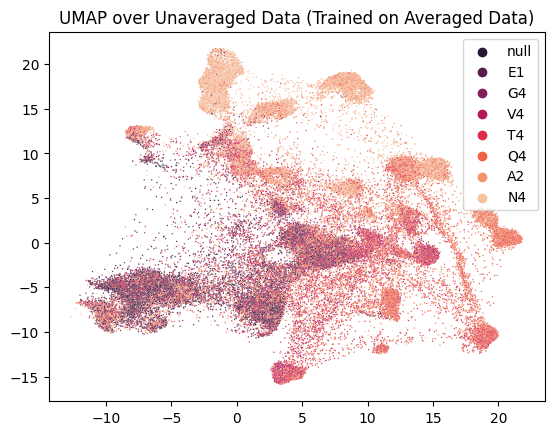

In [10]:
sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_anti[:SUBSET_SIZE]),
    palette="rocket", 
    hue_order=ANTIGENS, 
    s=1
)
plt.title("UMAP over Unaveraged Data (Trained on Averaged Data)")

Text(0.5, 1.0, 'UMAP over Unaveraged Data (Trained on Averaged Data)')

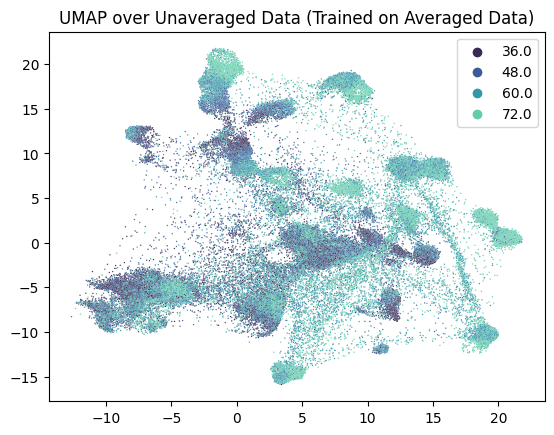

In [11]:
sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_time[:SUBSET_SIZE]), 
    palette="mako", 
    s=1
)
plt.title("UMAP over Unaveraged Data (Trained on Averaged Data)")

Text(0.5, 1.0, 'UMAP over Unaveraged Data (Trained on Averaged Data)')

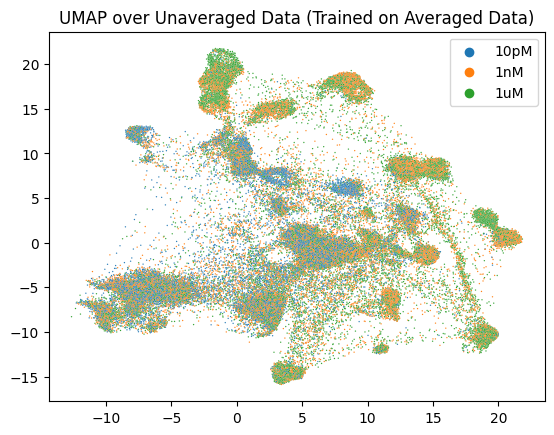

In [13]:
sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_concentration[:SUBSET_SIZE]), 
    # palette="mako", 
    s=1
)
plt.title("UMAP over Unaveraged Data (Trained on Averaged Data)")